In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Summer Internship/Week-2/student-por.csv')

Summary Statistics

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


Distribution Analysis:Histograms — All Numerical Columns

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns


Distribution Analysis:KDE (Kernel Density Estimate) Plots

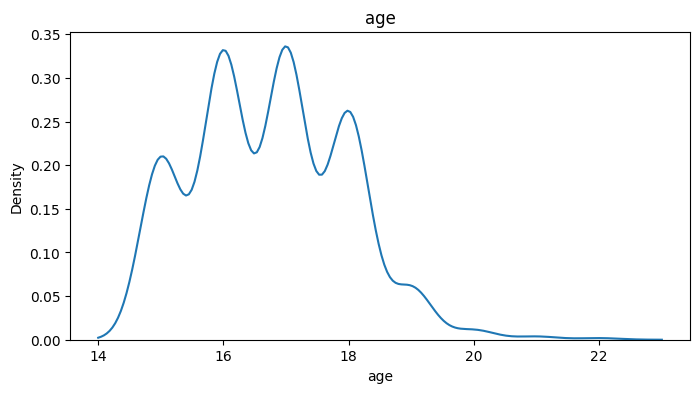

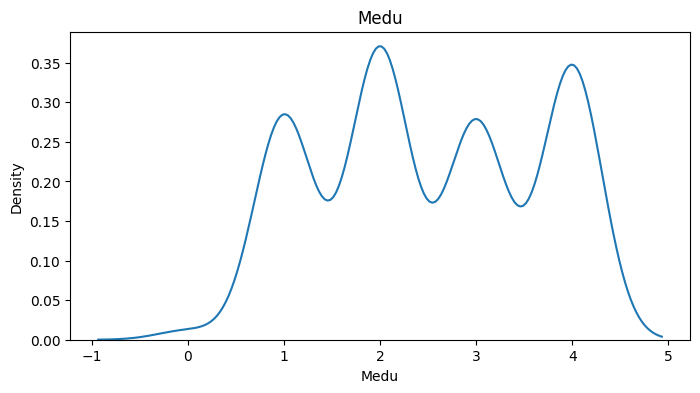

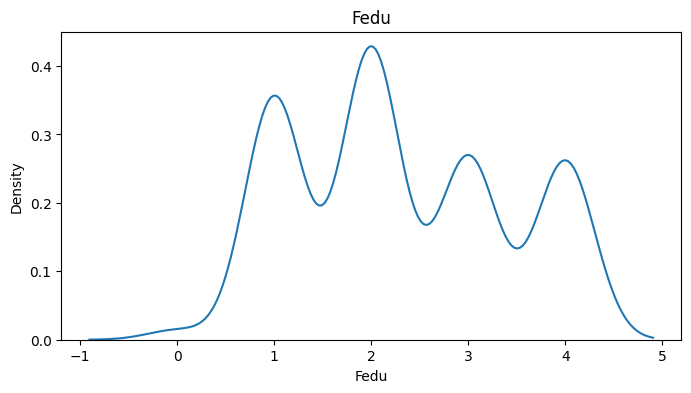

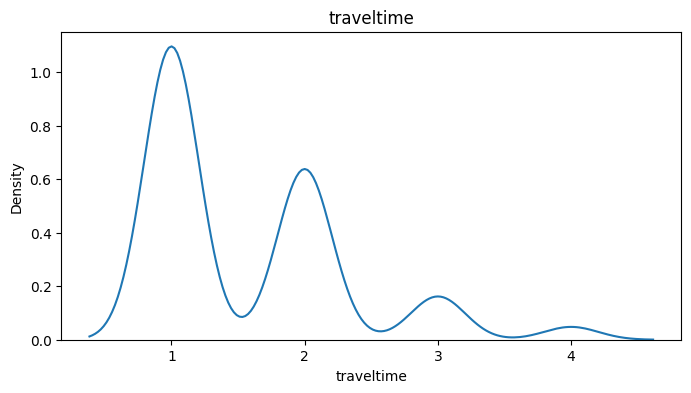

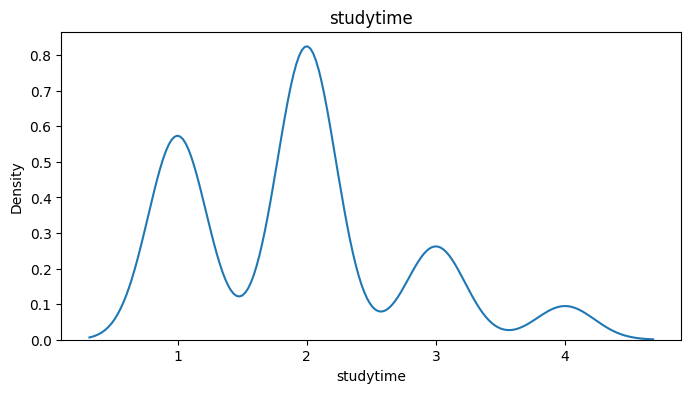

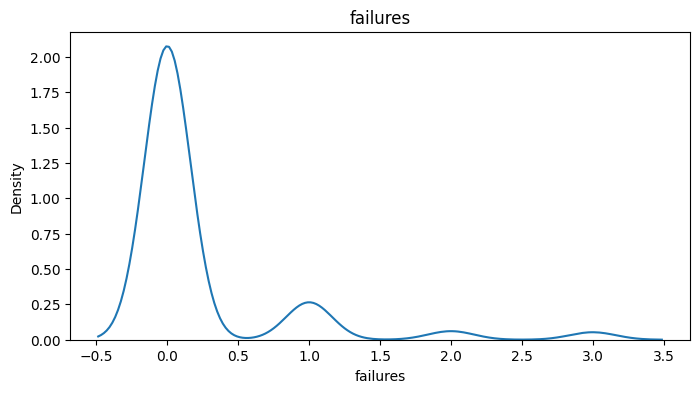

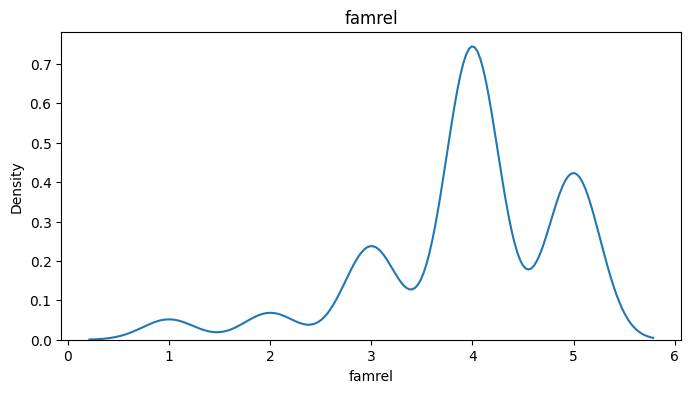

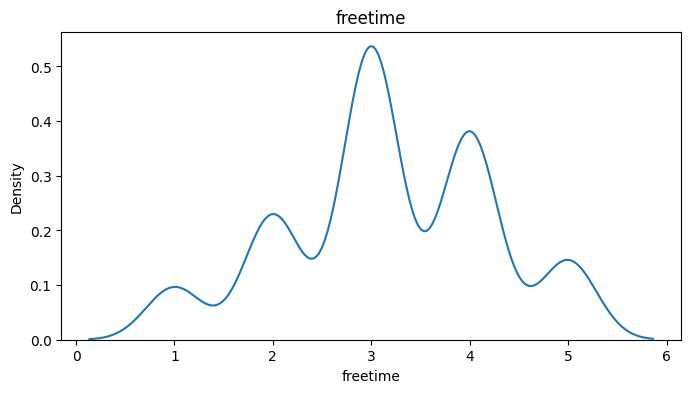

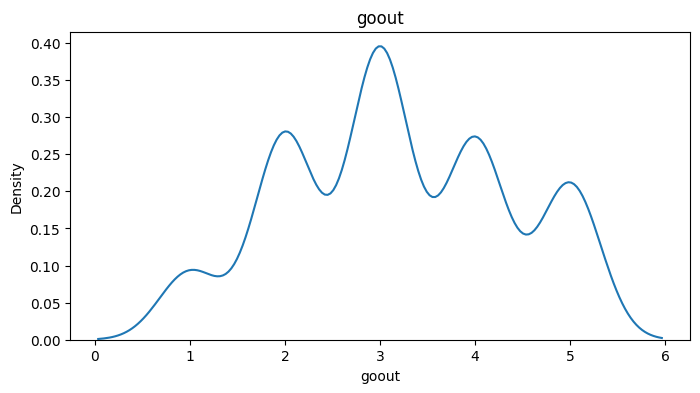

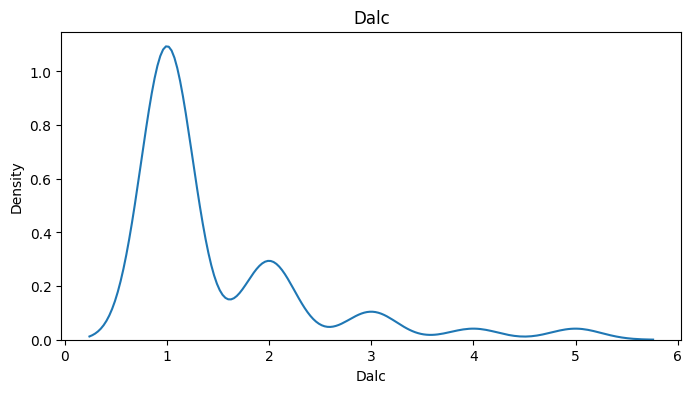

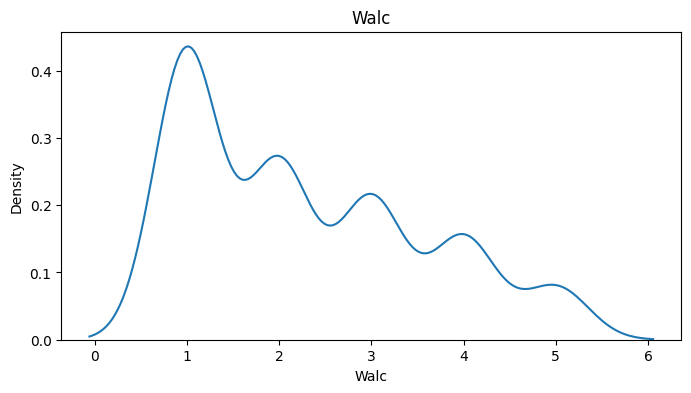

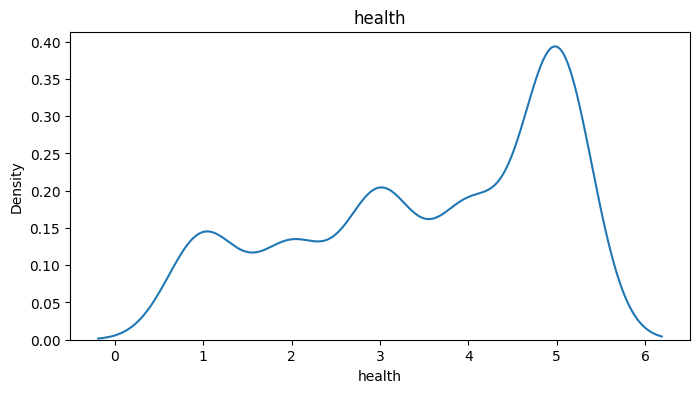

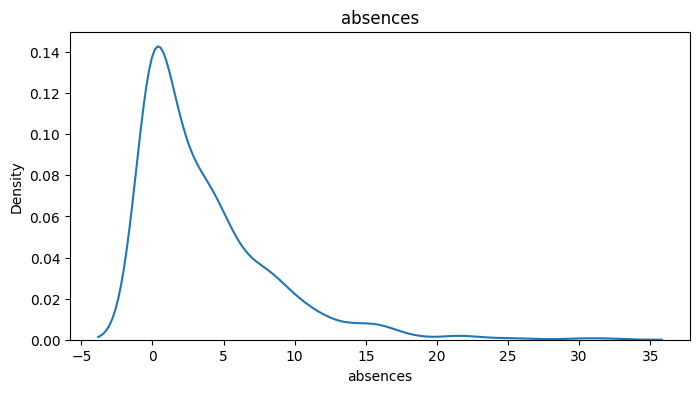

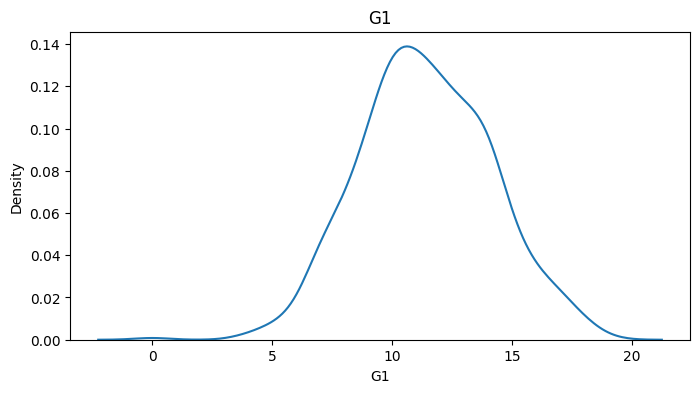

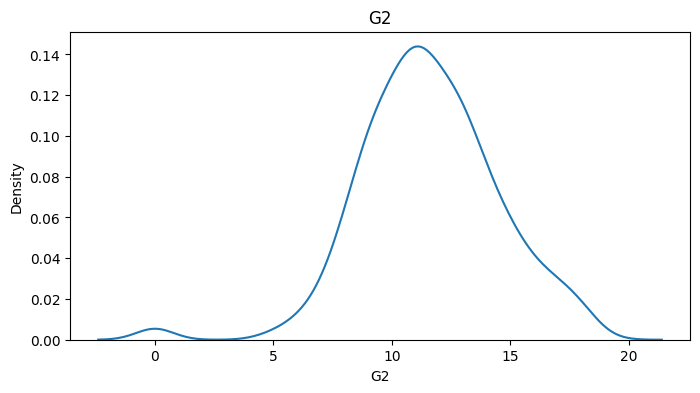

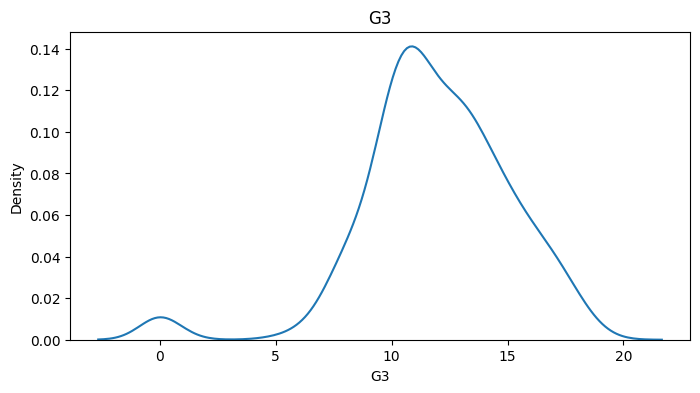

In [ ]:
for col in numeric_cols:
 plt.figure(figsize=(8, 4))
 sns.kdeplot(df[col])
 plt.title(col)
 plt.show()

Categorical Analysis:Count Plots


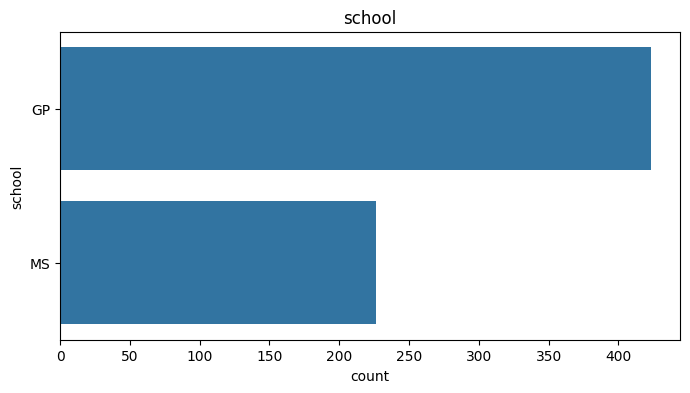

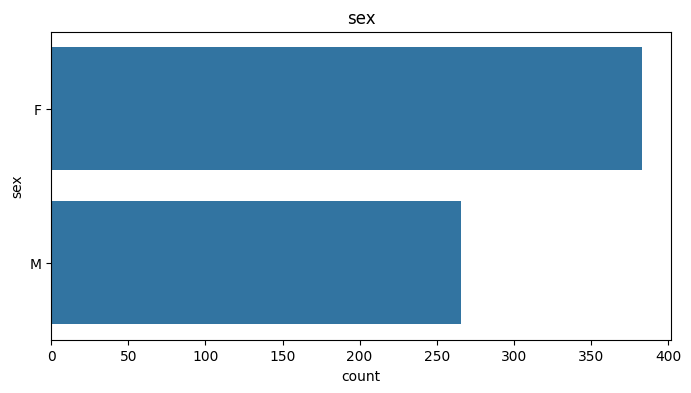

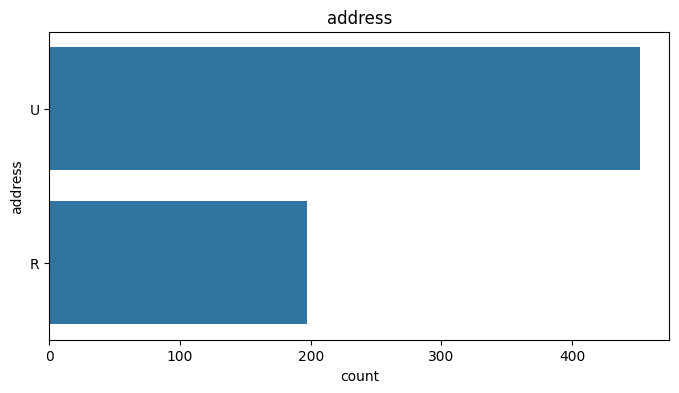

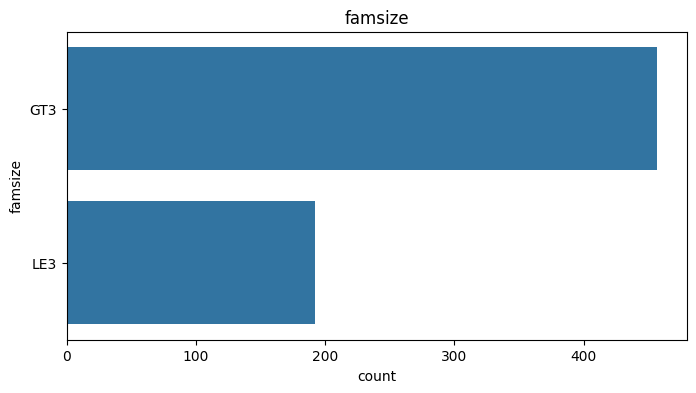

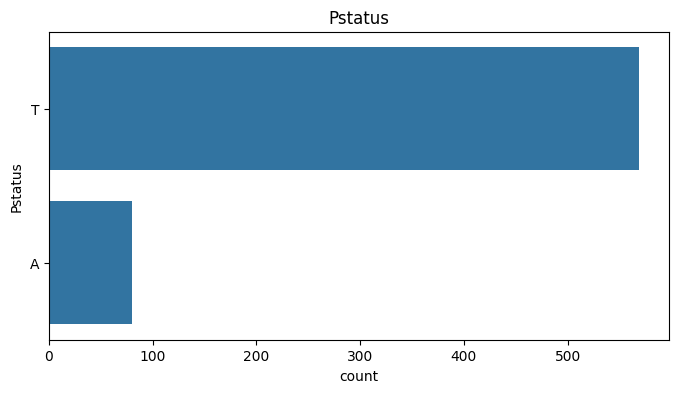

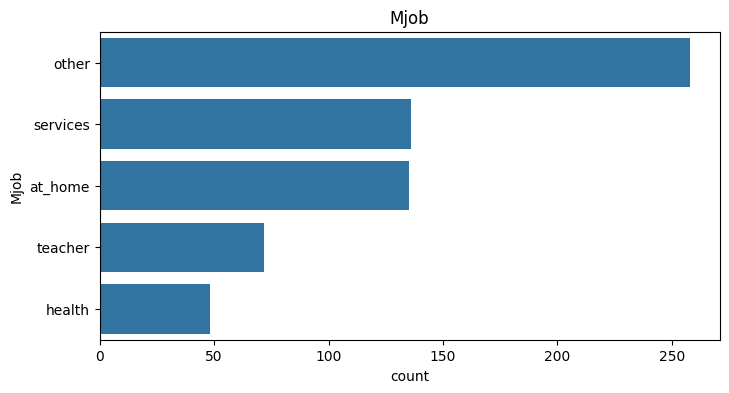

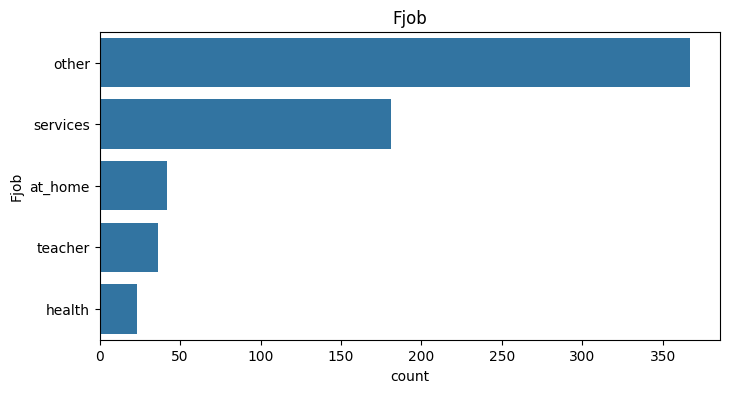

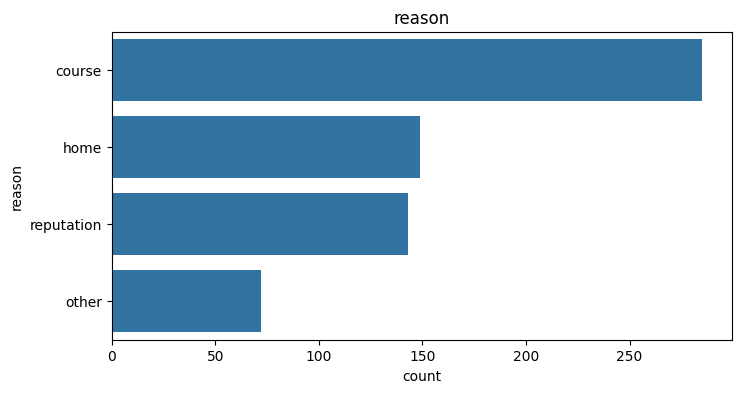

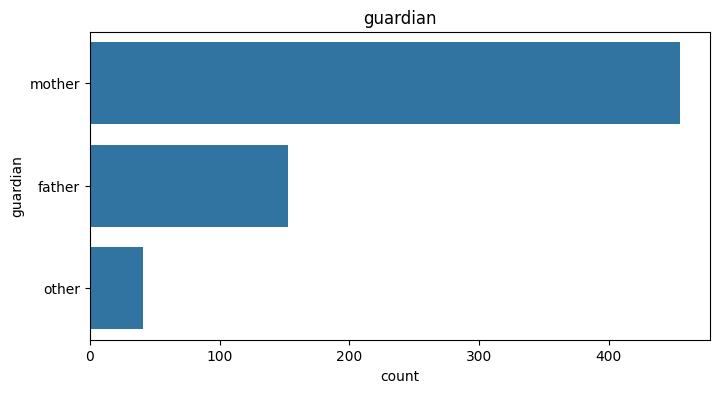

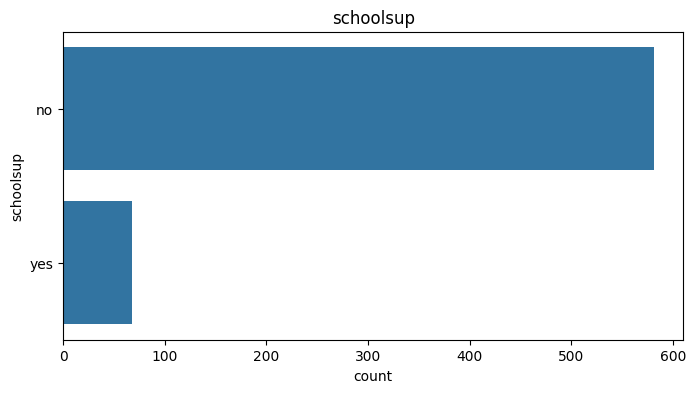

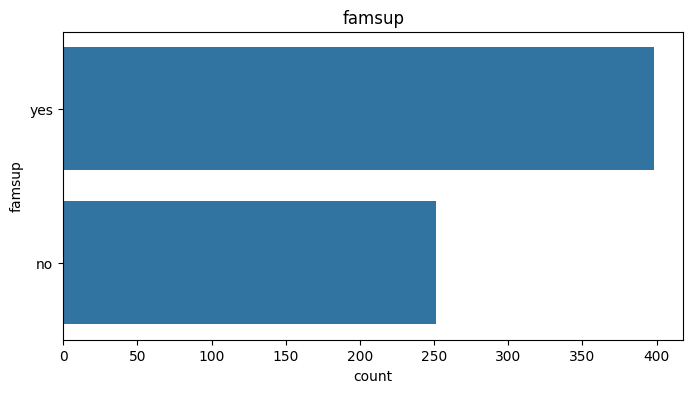

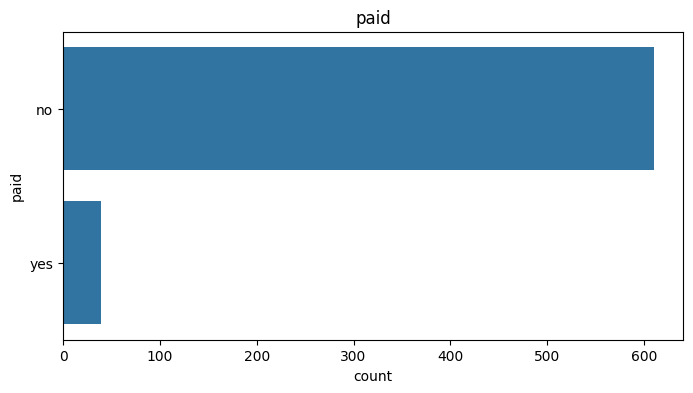

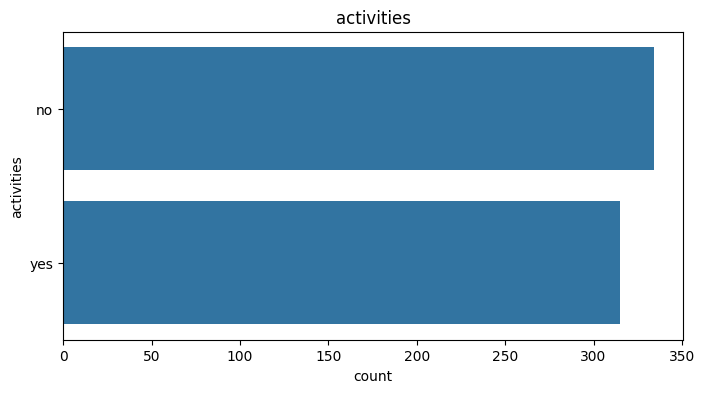

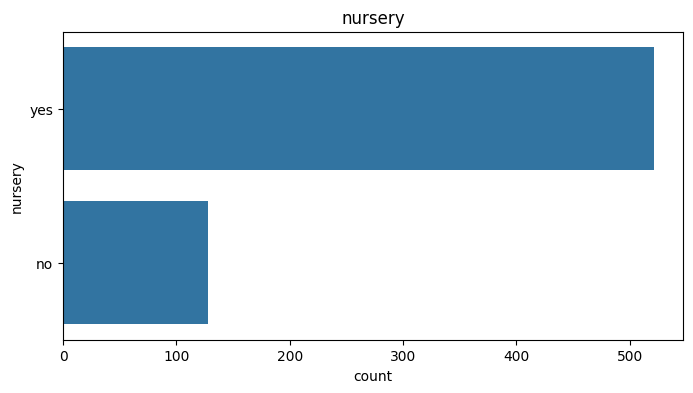

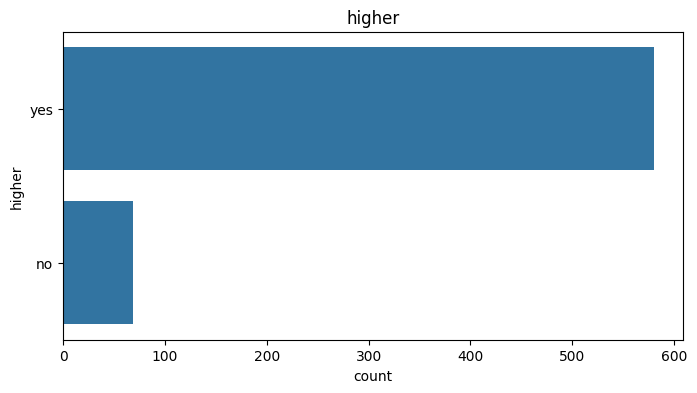

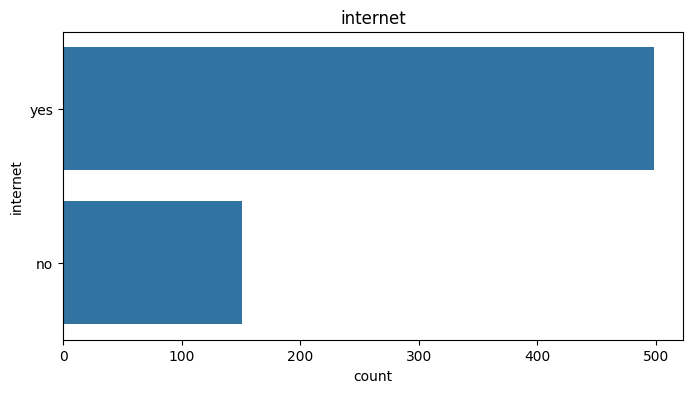

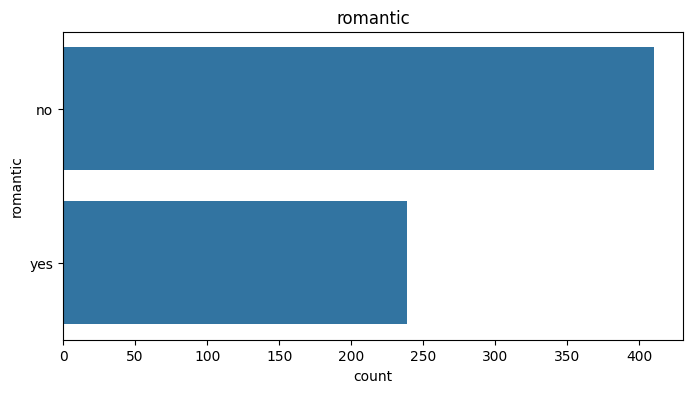

In [ ]:
for col in categorical_cols:
 plt.figure(figsize=(8, 4))
 sns.countplot(y=df[col], order=df[col].value_counts().index)
 plt.title(col)
 plt.show

Categorical Analysis:Frequency Tables

In [ ]:
for col in categorical_cols:
 print('\n', col)
 print(df[col].value_counts())


 school
school
GP    423
MS    226
Name: count, dtype: int64

 sex
sex
F    383
M    266
Name: count, dtype: int64

 address
address
U    452
R    197
Name: count, dtype: int64

 famsize
famsize
GT3    457
LE3    192
Name: count, dtype: int64

 Pstatus
Pstatus
T    569
A     80
Name: count, dtype: int64

 Mjob
Mjob
other       258
services    136
at_home     135
teacher      72
health       48
Name: count, dtype: int64

 Fjob
Fjob
other       367
services    181
at_home      42
teacher      36
health       23
Name: count, dtype: int64

 reason
reason
course        285
home          149
reputation    143
other          72
Name: count, dtype: int64

 guardian
guardian
mother    455
father    153
other      41
Name: count, dtype: int64

 schoolsup
schoolsup
no     581
yes     68
Name: count, dtype: int64

 famsup
famsup
yes    398
no     251
Name: count, dtype: int64

 paid
paid
no     610
yes     39
Name: count, dtype: int64

 activities
activities
no     334
yes    315
Name: count, dty

Correlation Analysis

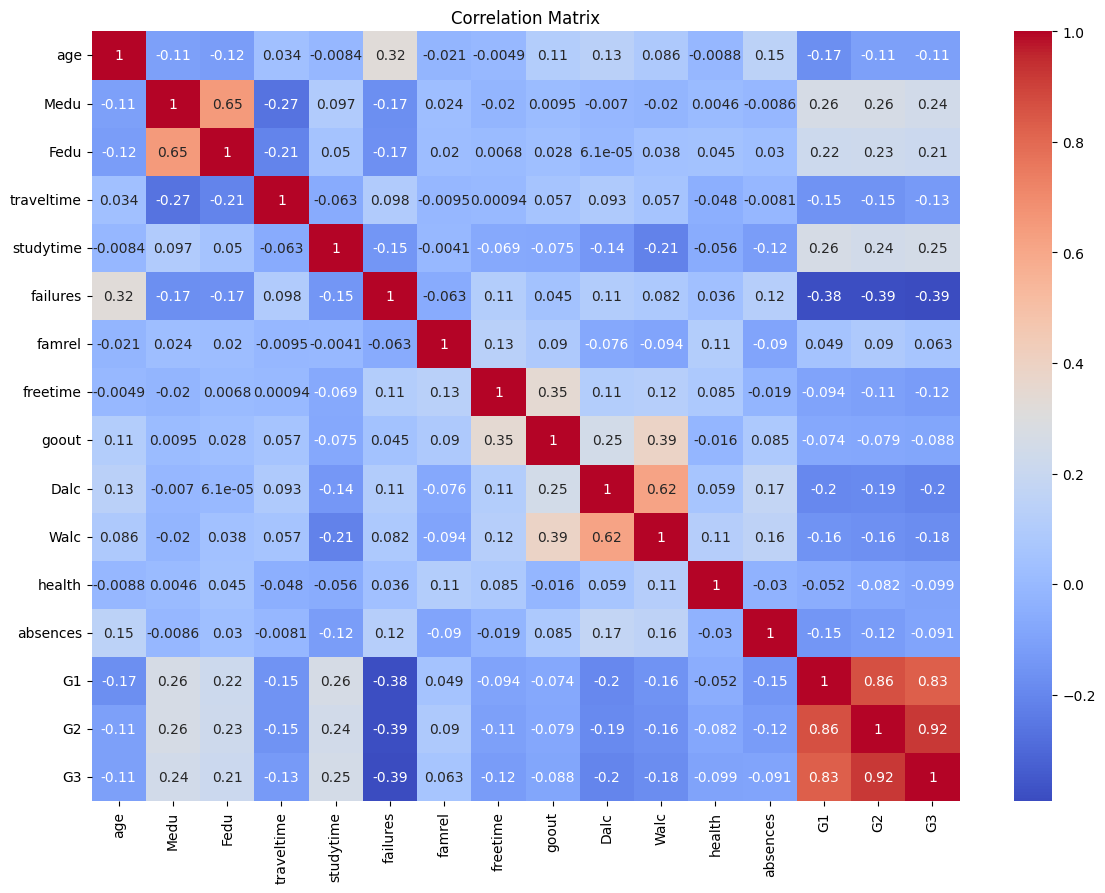

In [ ]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Pair plot

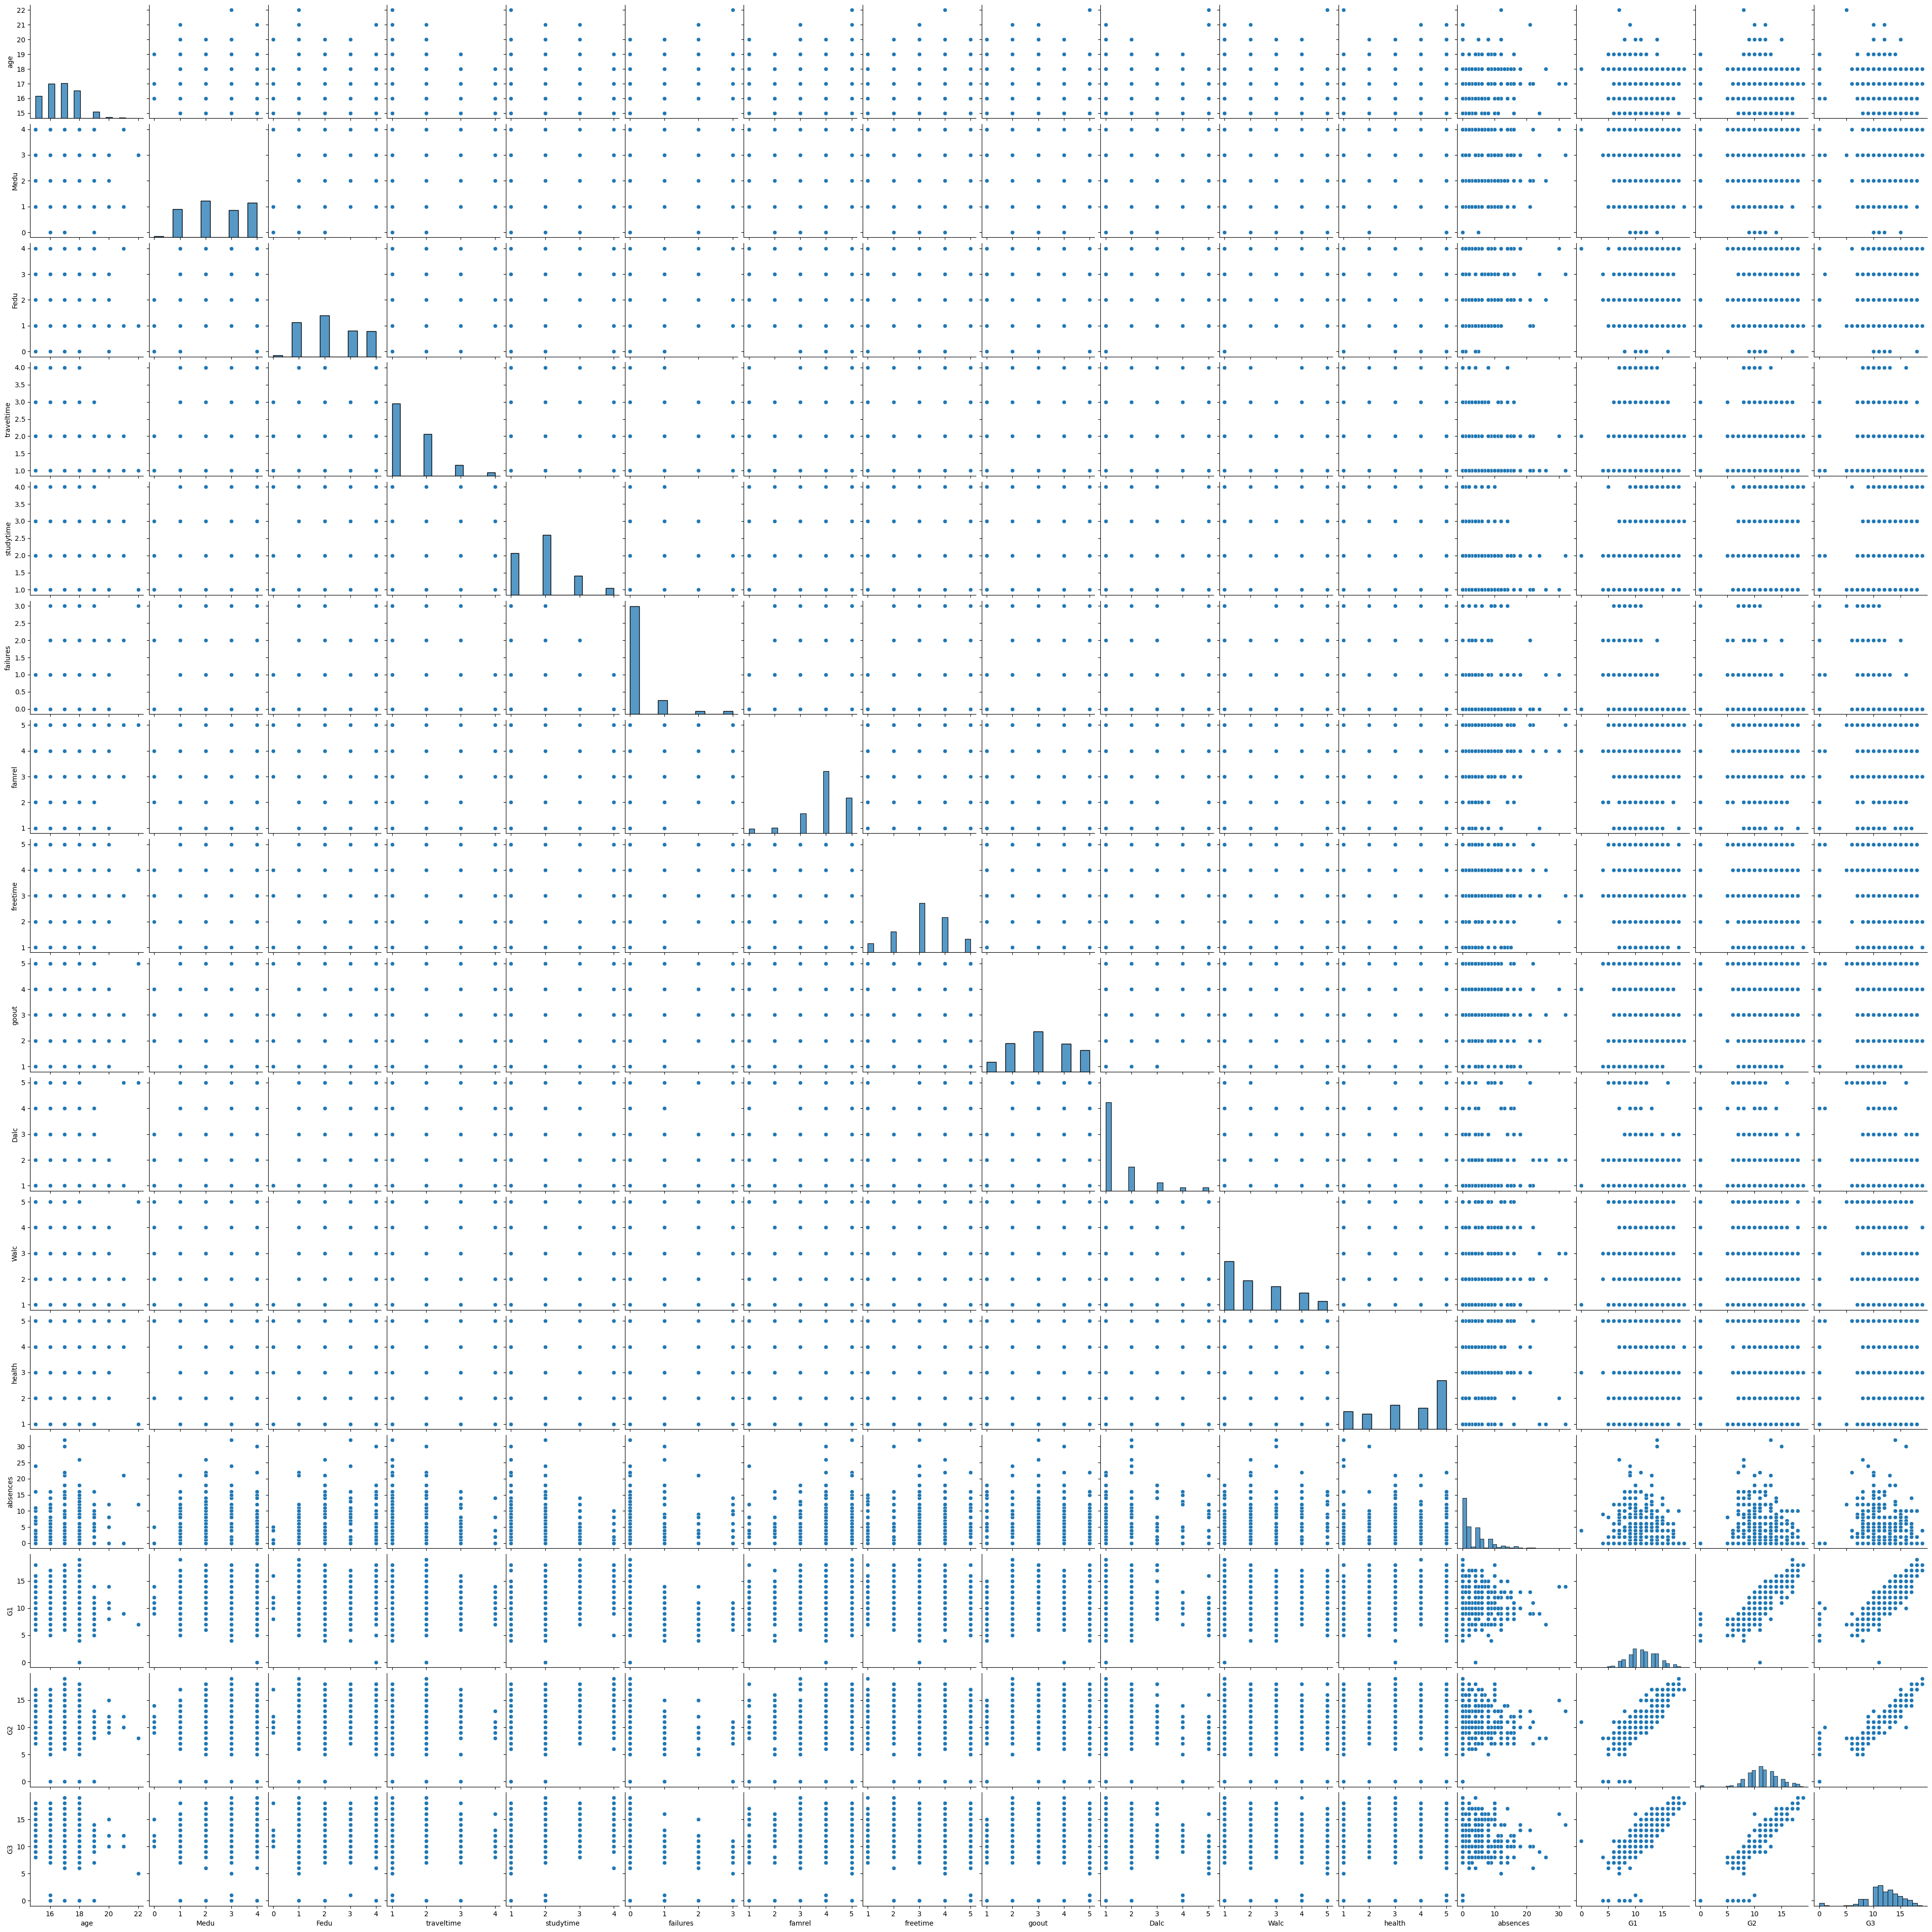

In [ ]:
sns.pairplot(df[numeric_cols])
plt.show()

 Skewness


In [ ]:
df[numeric_cols].skew()


,0
age,0.416795
Medu,-0.029950
Fedu,0.215343
traveltime,1.247648
studytime,0.699619
failures,3.092699
famrel,-1.105934
freetime,-0.181277
goout,-0.008580
Dalc,2.141913


Feature Relationships (Scatter Plots)

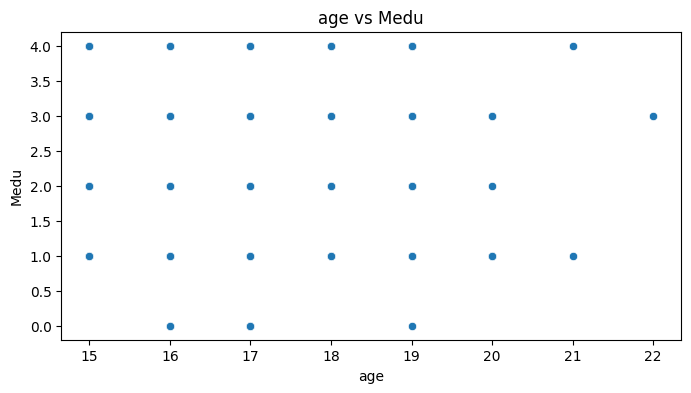

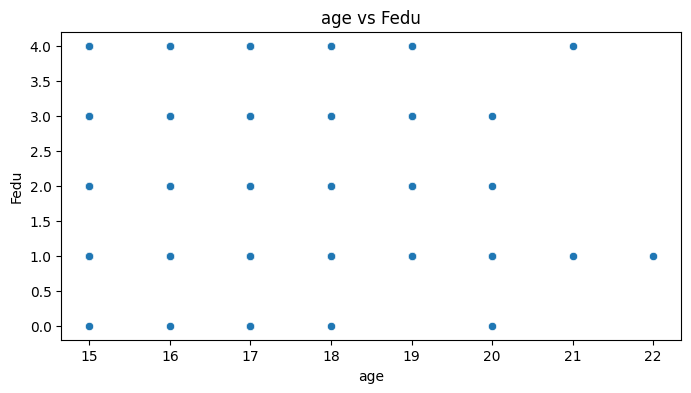

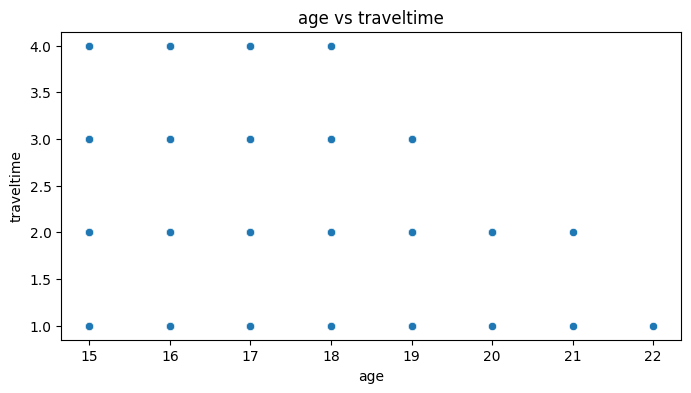

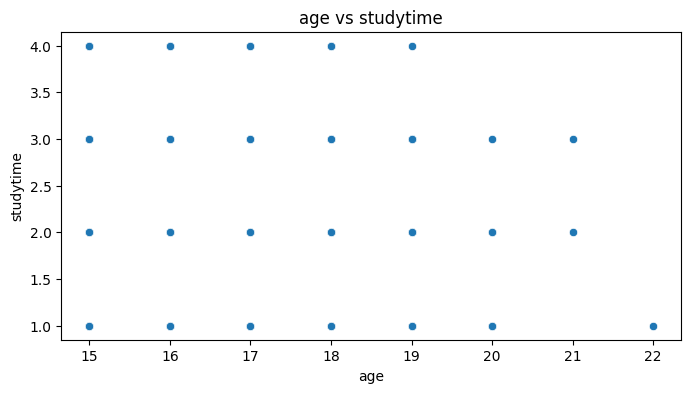

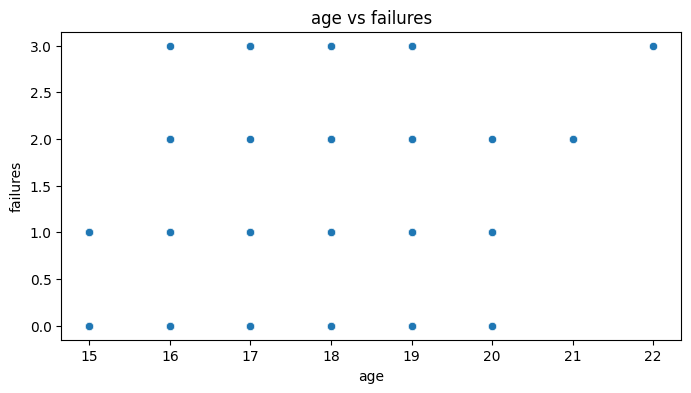

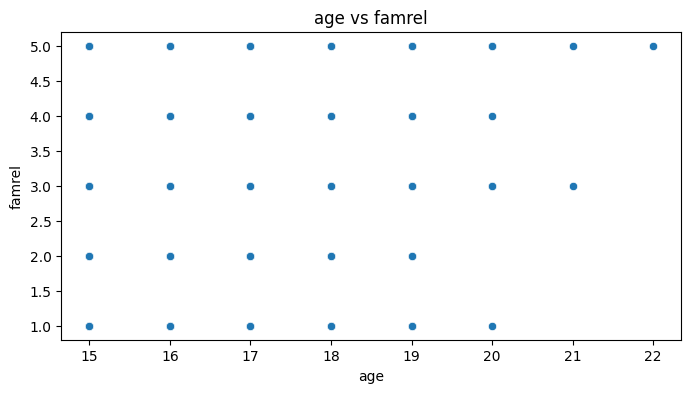

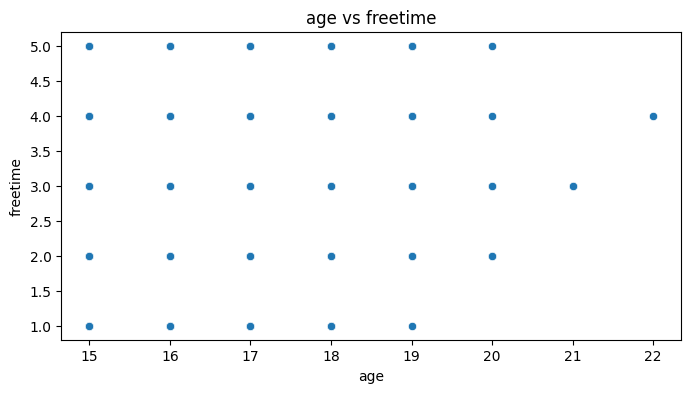

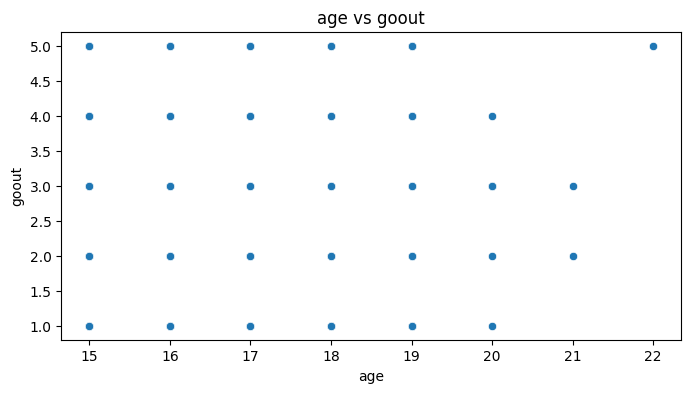

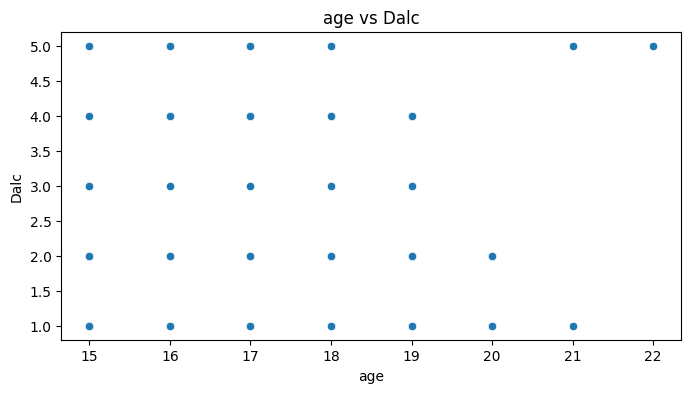

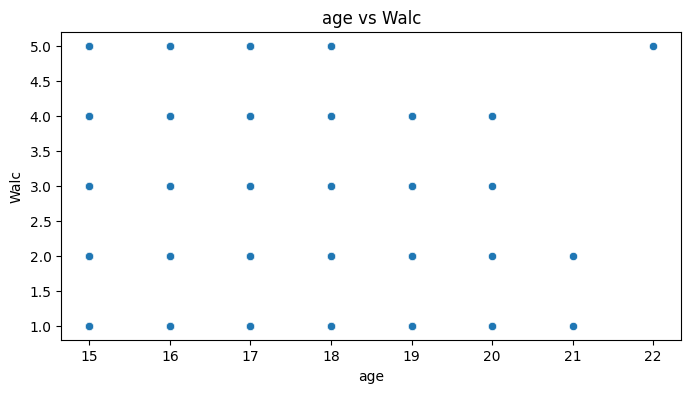

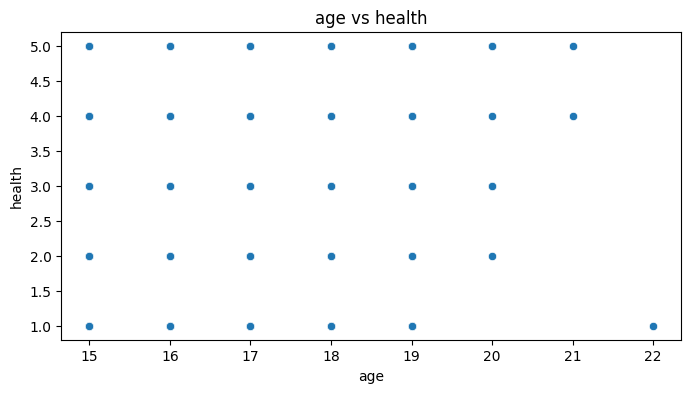

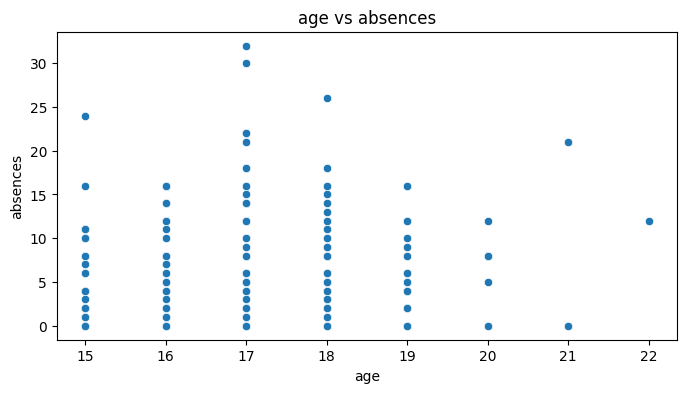

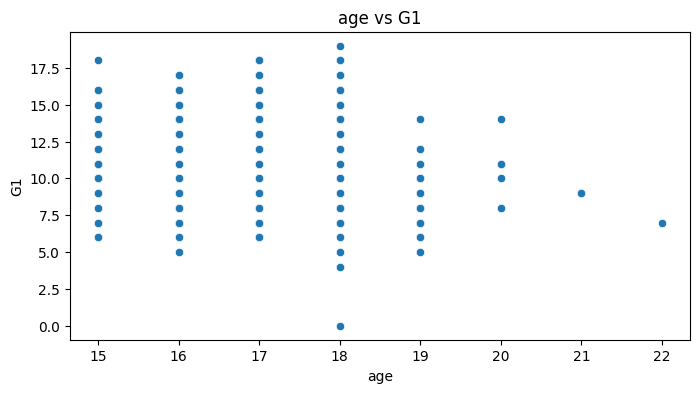

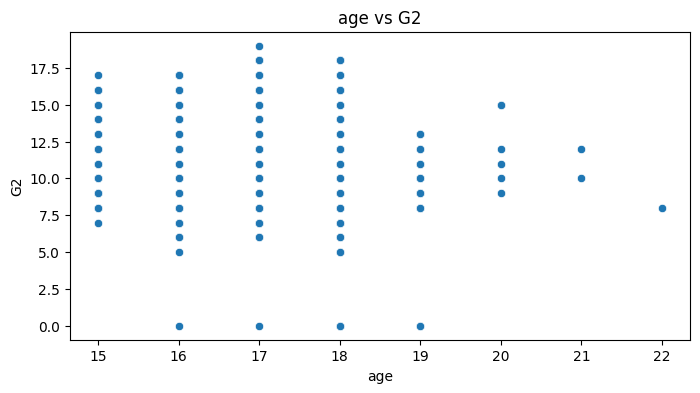

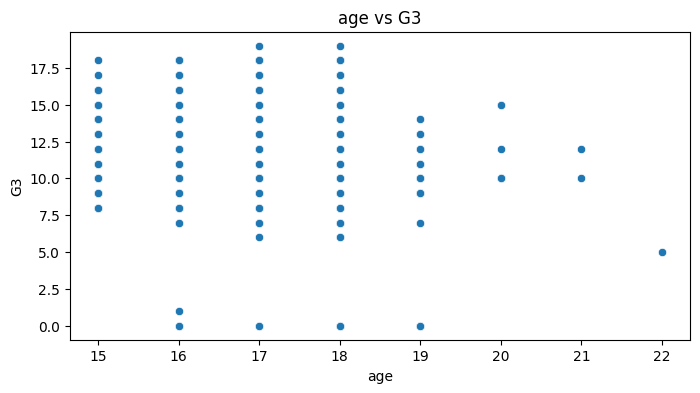

In [ ]:
for col in numeric_cols:
    if col != numeric_cols[0]:
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=df[numeric_cols[0]], y=df[col])

        plt.xlabel(numeric_cols[0])
        plt.ylabel(col)
        plt.title(f"{numeric_cols[0]} vs {col}")

        plt.show()

Feature Importance Exploration

In [ ]:
corr_matrix = abs(df[numeric_cols].corr())
corr_matrix


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,0.107832,0.121050,0.034490,0.008415,0.319968,0.020559,0.004910,0.112805,0.134768,0.086357,0.008750,0.149998,0.174322,0.107119,0.106505
Medu,0.107832,1.000000,0.647477,0.265079,0.097006,0.172210,0.024421,0.019686,0.009536,0.007018,0.019766,0.004614,0.008577,0.260472,0.264035,0.240151
Fedu,0.121050,0.647477,1.000000,0.208288,0.050400,0.165915,0.020256,0.006841,0.027690,0.000061,0.038445,0.044910,0.029859,0.217501,0.225139,0.211800
traveltime,0.034490,0.265079,0.208288,1.000000,0.063154,0.097730,0.009521,0.000937,0.057454,0.092824,0.057007,0.048261,0.008149,0.154120,0.154489,0.127173
studytime,0.008415,0.097006,0.050400,0.063154,1.000000,0.147441,0.004127,0.068829,0.075442,0.137585,0.214925,0.056433,0.118389,0.260875,0.240498,0.249789
failures,0.319968,0.172210,0.165915,0.097730,0.147441,1.000000,0.062645,0.108995,0.045078,0.105949,0.082266,0.035588,0.122779,0.384210,0.385782,0.393316
famrel,0.020559,0.024421,0.020256,0.009521,0.004127,0.062645,1.000000,0.129216,0.089707,0.075767,0.093511,0.109559,0.089534,0.048795,0.089588,0.063361
freetime,0.004910,0.019686,0.006841,0.000937,0.068829,0.108995,0.129216,1.000000,0.346352,0.109904,0.120244,0.084526,0.018716,0.094497,0.106678,0.122705
goout,0.112805,0.009536,0.027690,0.057454,0.075442,0.045078,0.089707,0.346352,1.000000,0.245126,0.388680,0.015741,0.085374,0.074053,0.079469,0.087641
Dalc,0.134768,0.007018,0.000061,0.092824,0.137585,0.105949,0.075767,0.109904,0.245126,1.000000,0.616561,0.059067,0.172952,0.195171,0.189480,0.204719


 EDA Summary Report

In [ ]:
eda_report = pd.DataFrame({
 'Column': df.columns,
 'MissingValues': df.isnull().sum(),
 'UniqueValues': df.nunique(),
 'DataType': df.dtypes
})
eda_report

,Column,MissingValues,UniqueValues,DataType
school,school,0,2,object
sex,sex,0,2,object
age,age,0,8,int64
address,address,0,2,object
famsize,famsize,0,2,object
Pstatus,Pstatus,0,2,object
Medu,Medu,0,5,int64
Fedu,Fedu,0,5,int64
Mjob,Mjob,0,5,object
Fjob,Fjob,0,5,object
